# 03. 逆ラプラス変換と部分分数分解 — s 領域から時間へ戻す

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 9. Application |
| Advanced | 10. Exercises / 11. Advanced Notes |

> 有理関数 $F(s)$ を部分分数に割り、単純極・重根・複素極を表で時間へ戻す。

In [1]:
# Shared setup: make laplace_book importable, fix seeds, inline + plotly rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import laplace_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "laplace_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display

from laplace_book import transforms, systems, circuits, plotting, datasets, widgets
from laplace_book.transforms import t, s, L, Linv, numeric_laplace, partial_fractions

import plotly.io as pio
pio.renderers.default = "notebook_connected"

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)
sp.init_printing()

## 1. Big Picture / 2. Problem

$s$ 領域で代数的に $F(s)$ を得たら、最後に **時間へ戻す** 必要があります。

$$ f(t) = \mathcal{L}^{-1}\{F(s)\}. $$

実務ではほとんどの $F(s)$ が **有理関数**(多項式/多項式)。鍵は **部分分数分解** で、
変換表で逆変換できる小片に割ることです。

## 3. Intuition / 4. 変換表(逆向き)

| $F(s)$ | $f(t)$ |
|---|---|
| $1/(s+a)$ | $e^{-at}$ |
| $1/(s+a)^2$ | $t\,e^{-at}$ (重根 → $t$ が掛かる) |
| $\omega/((s+a)^2+\omega^2)$ | $e^{-at}\sin\omega t$ (複素極 → 減衰振動) |
| $(s+a)/((s+a)^2+\omega^2)$ | $e^{-at}\cos\omega t$ |

**単純極 → 指数**、**重根 → $t^k$ 付き**、**複素共役極 → 減衰振動**、と覚えると見通しが良いです。

## 5. Definition / 6. Computation — 単純極

$F(s)=\dfrac{s+3}{(s+1)(s+2)}$ を部分分数に割り、各片を逆変換します。

In [2]:
F = (s + 3) / ((s + 1) * (s + 2))
print("partial fractions:")
display(partial_fractions(F))      # 2/(s+1) - 1/(s+2)
print("inverse transform f(t):")
display(Linv(F))                   # 2 e^{-t} - e^{-2t}

partial fractions:


inverse transform f(t):


## 7. 重根の場合

$F(s)=\dfrac{1}{(s+1)^2}$ のような重根は、$t$ が掛かった項を生みます。

In [3]:
display(Linv(1 / (s + 1) ** 2))            # t e^{-t}
display(Linv(1 / (s * (s + 1) ** 2)))      # mixes a constant, e^{-t}, and t e^{-t}

## 8. 複素極の場合 → 減衰振動

分母が実根を持たない2次式 $s^2+2s+5=(s+1)^2+4$ は、複素共役極 $s=-1\pm2i$。逆変換は減衰振動です。

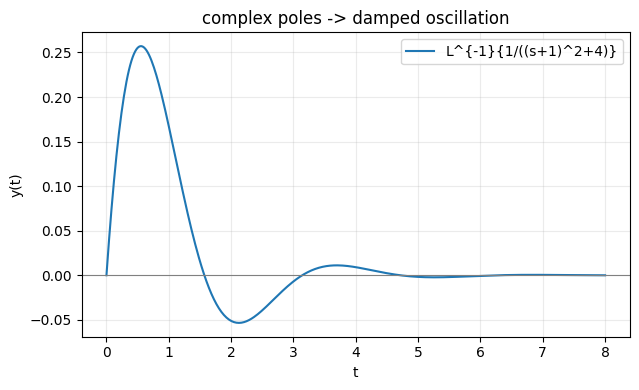

In [4]:
F = 1 / (s**2 + 2 * s + 5)
f = sp.simplify(Linv(F))
display(f)                                  # e^{-t} sin(2t)/2

tt = np.linspace(0, 8, 400)
yfun = transforms.as_function(f)
plotting.plot_time_responses(tt, [yfun(tt)], labels=["L^{-1}{1/((s+1)^2+4)}"],
                             title="complex poles -> damped oscillation")
plt.tight_layout()

## 9. Application / 10. Failure Mode — 逆変換の注意点

- **一意性**: 片側ラプラス変換では $t\ge0$ で(良い条件のもとで)一意。ただし両側変換や ROC を無視すると別解が出る。
- **数値逆変換は難しい**: ブロムウィッチ積分の直接数値化は悪条件。実務では部分分数 + 表が基本。
- 本書では SymPy の記号逆変換を主に使う(`Linv`)。

## 9b. 数値逆ラプラス変換 (Applied)

$F(s)$ が記号で扱えない・複雑なときは、$F(s)$ を **数値的に** 時間へ戻す方法がある。本書は2つを用意:

- **Gaver-Stehfest** (`inverse_laplace_stehfest`): 実軸上の $F(s)$ だけを使う簡便法。なめらかで減衰する
  $f(t)$ には強いが、振動には弱い。
- **Talbot** (`inverse_laplace_talbot`): 積分路を左半面へ変形する方法。振動・減衰のどちらにも強い。

既知ペアで比べ、「なぜ数値逆変換が難しいか」を体感する。

e^{-t} :  Stehfest max err = 2.01602750264894e-05 | Talbot max err = 9.938519979213467e-09
sin(3t):  Stehfest max err = 0.9429317240182221 | Talbot max err = 4.710734358148727e-09


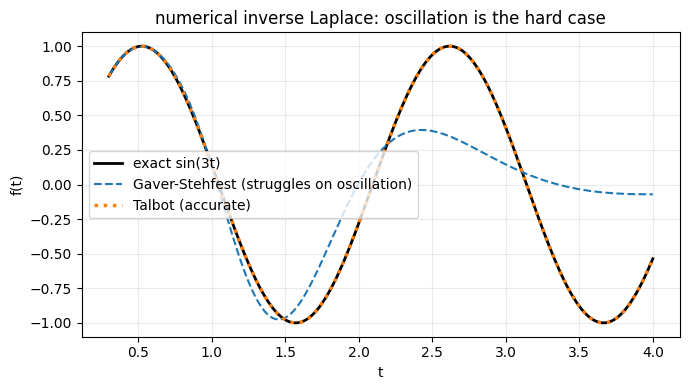

In [5]:
tt = np.linspace(0.3, 4, 200)

# Smooth/decaying target e^{-t}: both methods are accurate.
exact = np.exp(-tt)
y_st = transforms.inverse_laplace_stehfest(lambda S: 1 / (S + 1), tt)
y_tb = transforms.inverse_laplace_talbot(lambda S: 1 / (S + 1), tt)
print("e^{-t} :  Stehfest max err =", np.max(np.abs(y_st - exact)),
      "| Talbot max err =", np.max(np.abs(y_tb - exact)))

# Oscillatory target sin(3t): Stehfest struggles, Talbot stays accurate.
exact_o = np.sin(3 * tt)
o_st = transforms.inverse_laplace_stehfest(lambda S: 3 / (S**2 + 9), tt)
o_tb = transforms.inverse_laplace_talbot(lambda S: 3 / (S**2 + 9), tt)
print("sin(3t):  Stehfest max err =", np.max(np.abs(o_st - exact_o)),
      "| Talbot max err =", np.max(np.abs(o_tb - exact_o)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tt, exact_o, "k", lw=2, label="exact sin(3t)")
ax.plot(tt, o_st, "--", label="Gaver-Stehfest (struggles on oscillation)")
ax.plot(tt, o_tb, ":", lw=2.5, label="Talbot (accurate)")
ax.set_xlabel("t"); ax.set_ylabel("f(t)"); ax.legend(); ax.grid(alpha=0.25)
ax.set_title("numerical inverse Laplace: oscillation is the hard case")
plt.tight_layout()

## 11. Exercises / Advanced & TODO

- **演習**: $\dfrac{2s+1}{s^2+s}$、$\dfrac{1}{(s+2)^3}$、$\dfrac{s}{s^2+4}$ を逆変換せよ。
- **Advanced**: 留数(residue)による逆変換 $f(t)=\sum \operatorname{Res}[F(s)e^{st}]$ をまとめよ。

> **TODO(今後の拡張)**: ヘヴィサイドの展開定理の手計算、`scipy.signal.residue` による数値部分分数、
> むだ時間 $e^{-as}$ を含む像の逆変換(時間シフト)を追加。